In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 6)

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/PJME_hourly.csv')

df.columns = ['datetime', 'energy_mw']
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')
df = df.sort_index()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(10)

Shape: (145366, 1)
Date range: 2002-01-01 01:00:00 → 2018-08-03 00:00:00
Missing values: 0


,energy_mw
datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0
2002-01-01 06:00:00,28654.0
2002-01-01 07:00:00,29308.0
2002-01-01 08:00:00,29595.0
2002-01-01 09:00:00,29943.0


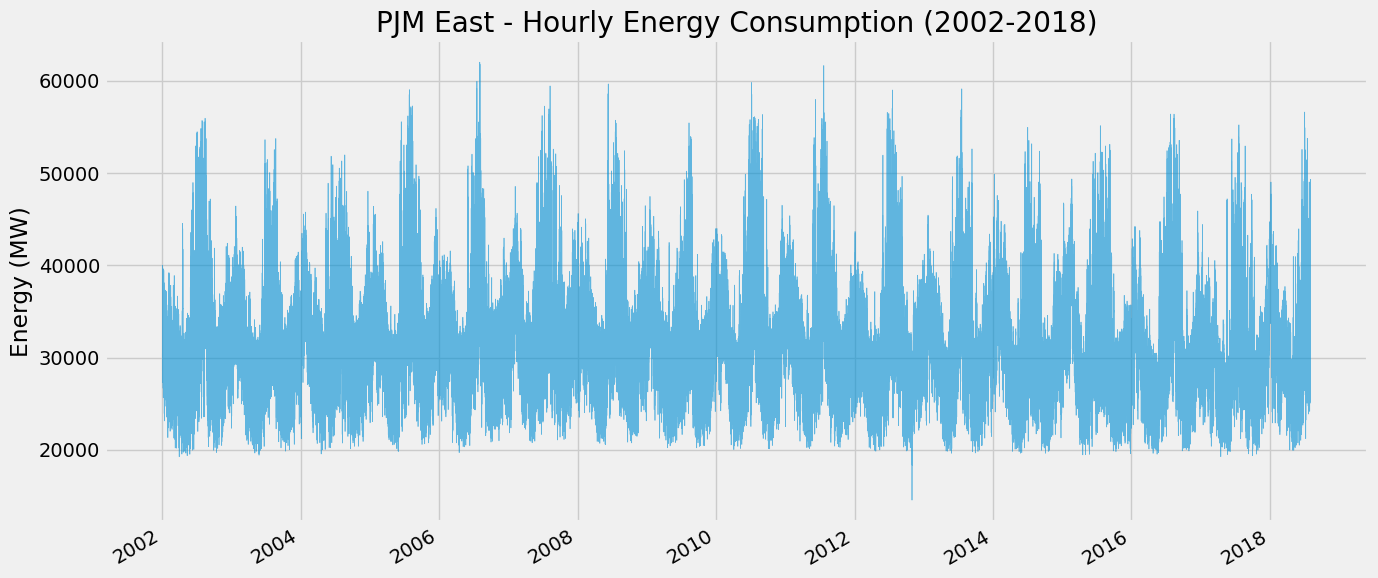

In [4]:
df.plot(title='PJM East - Hourly Energy Consumption (2002-2018)',
        ylabel='Energy (MW)', xlabel='', legend=False, alpha=0.6, linewidth=0.5)
plt.tight_layout()
plt.show()

In [5]:
df.describe

<bound method NDFrame.describe of                      energy_mw
datetime                      
2002-01-01 01:00:00    30393.0
2002-01-01 02:00:00    29265.0
2002-01-01 03:00:00    28357.0
2002-01-01 04:00:00    27899.0
2002-01-01 05:00:00    28057.0
...                        ...
2018-08-02 20:00:00    44057.0
2018-08-02 21:00:00    43256.0
2018-08-02 22:00:00    41552.0
2018-08-02 23:00:00    38500.0
2018-08-03 00:00:00    35486.0

[145366 rows x 1 columns]>

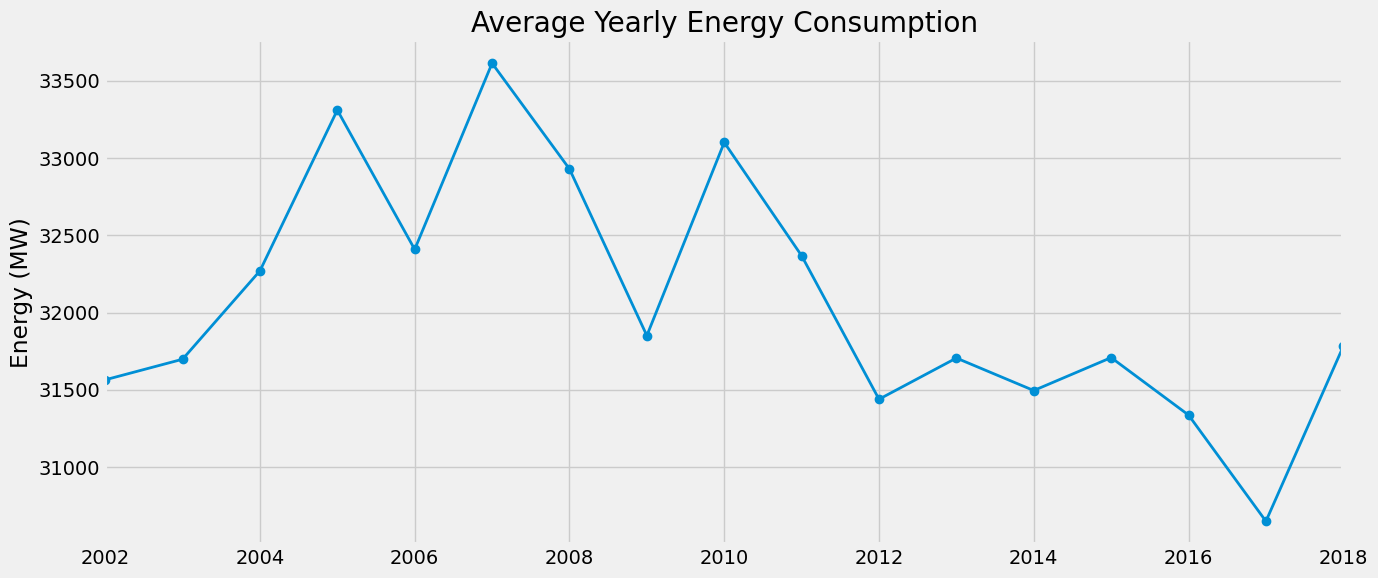

In [6]:
df_yearly = df.resample('YE').mean()
df_yearly.plot(title='Average Yearly Energy Consumption', 
               ylabel='Energy (MW)', xlabel='', legend=False,
               marker='o', linewidth=2)
plt.tight_layout()
plt.show()

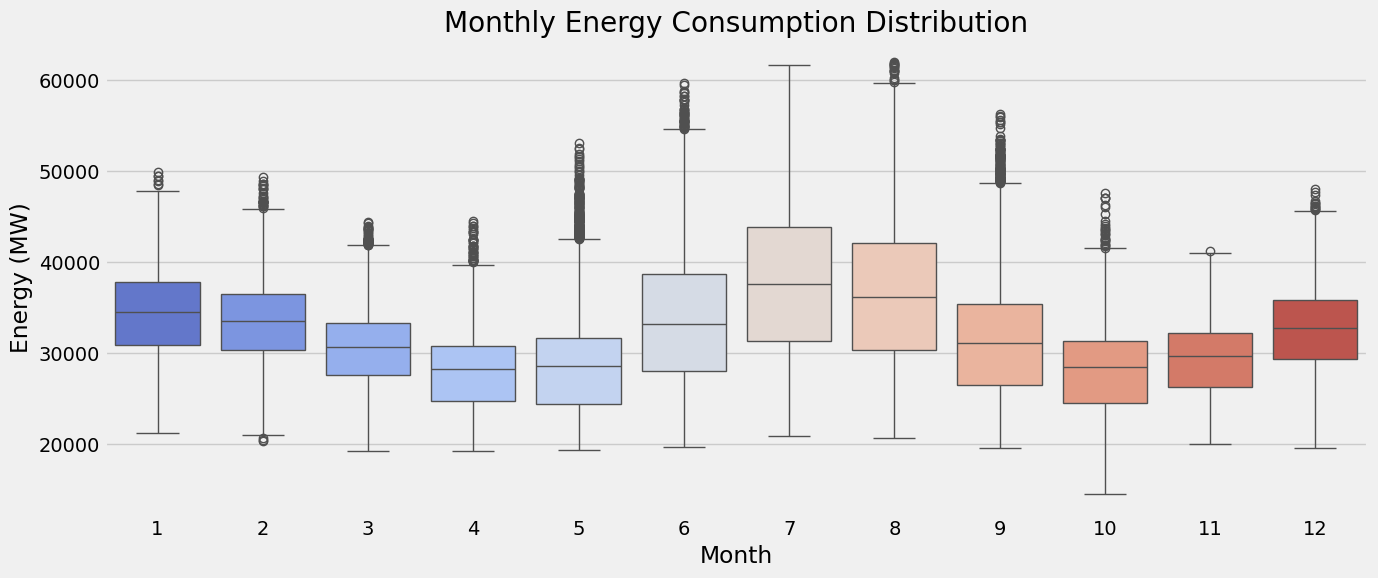

In [7]:
df['month'] = df.index.month
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='month', y='energy_mw', ax=ax, palette='coolwarm')
ax.set_title('Monthly Energy Consumption Distribution')
ax.set_xlabel('Month')
ax.set_ylabel('Energy (MW)')
plt.tight_layout()
plt.show()

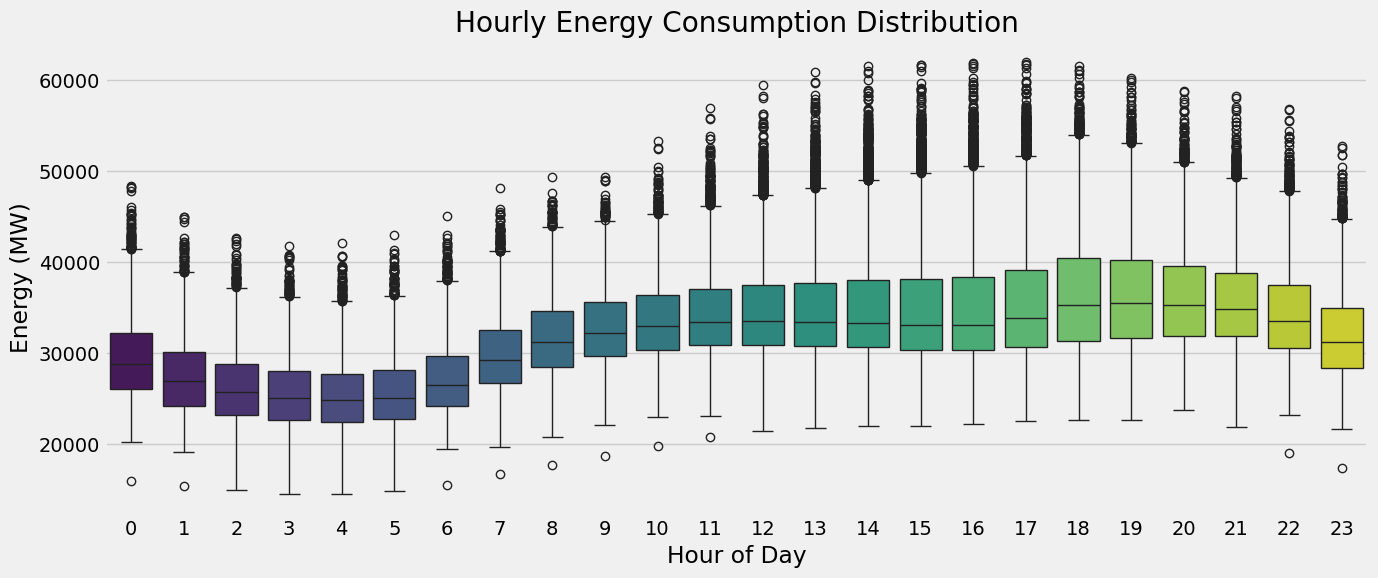

In [8]:
df['hour'] = df.index.hour
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='hour', y='energy_mw', ax=ax, palette='viridis')
ax.set_title('Hourly Energy Consumption Distribution')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Energy (MW)')
plt.tight_layout()
plt.show()

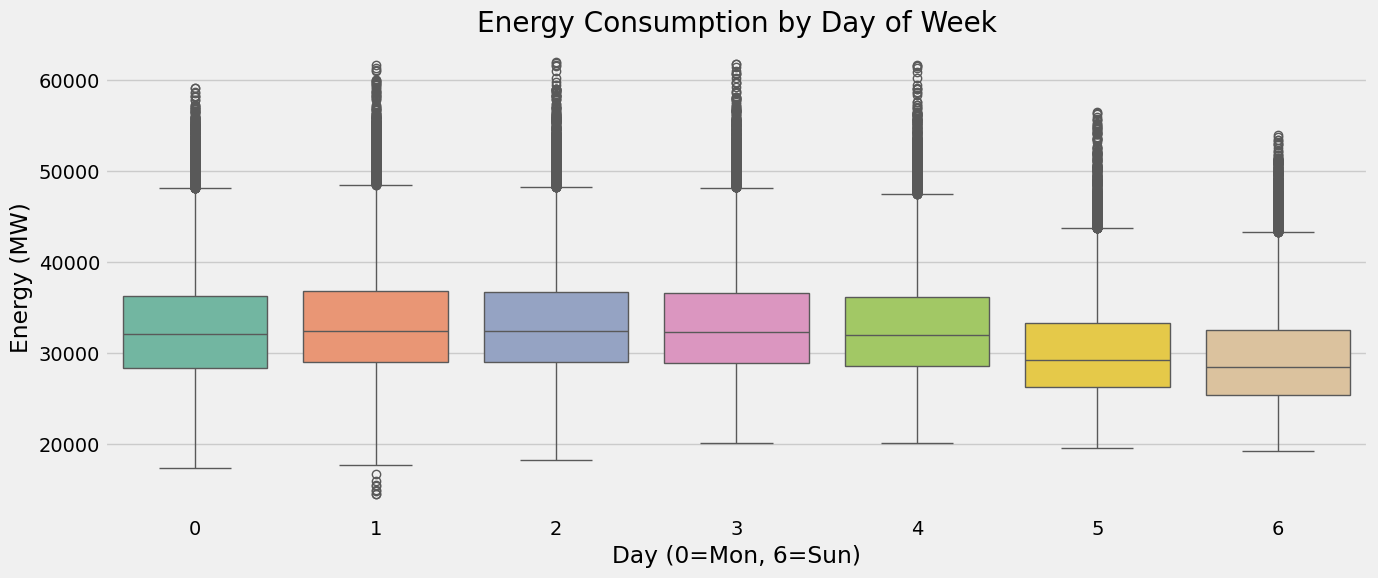

In [9]:
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='dayofweek', y='energy_mw', ax=ax, palette='Set2')
ax.set_title('Energy Consumption by Day of Week')
ax.set_xlabel('Day (0=Mon, 6=Sun)')
ax.set_ylabel('Energy (MW)')
plt.tight_layout()
plt.show()

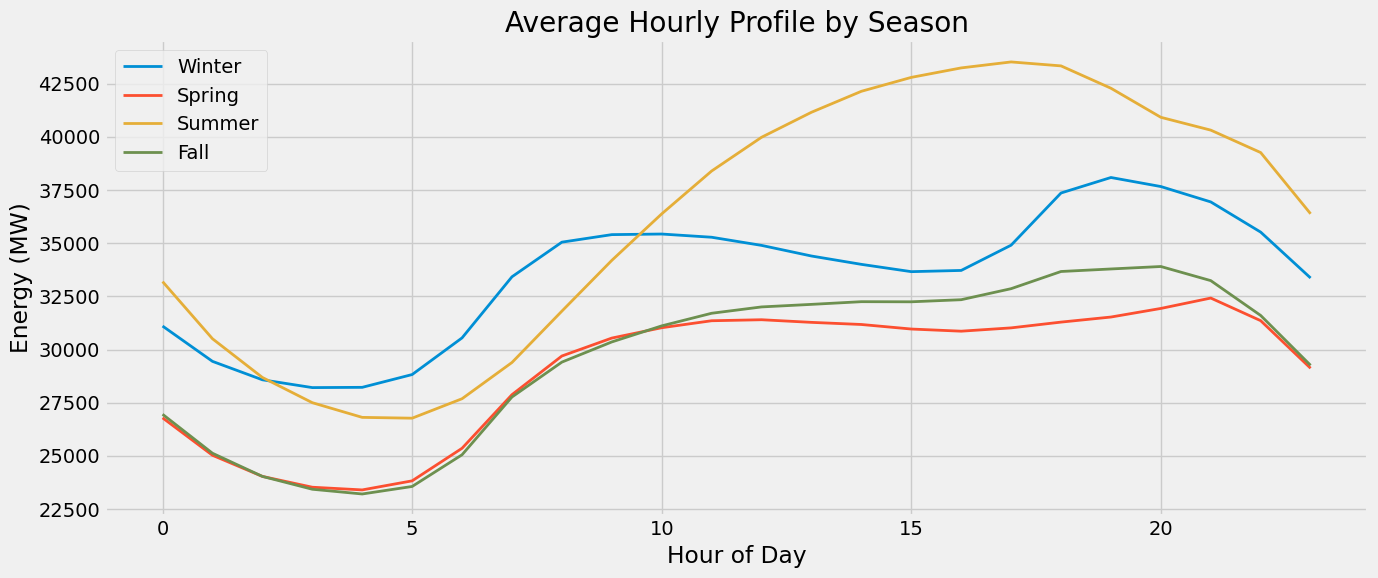

In [10]:
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

seasonal_hourly = df.groupby(['season', 'hour'])['energy_mw'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    ax.plot(seasonal_hourly[season], label=season, linewidth=2)

ax.set_title('Average Hourly Profile by Season')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.show()

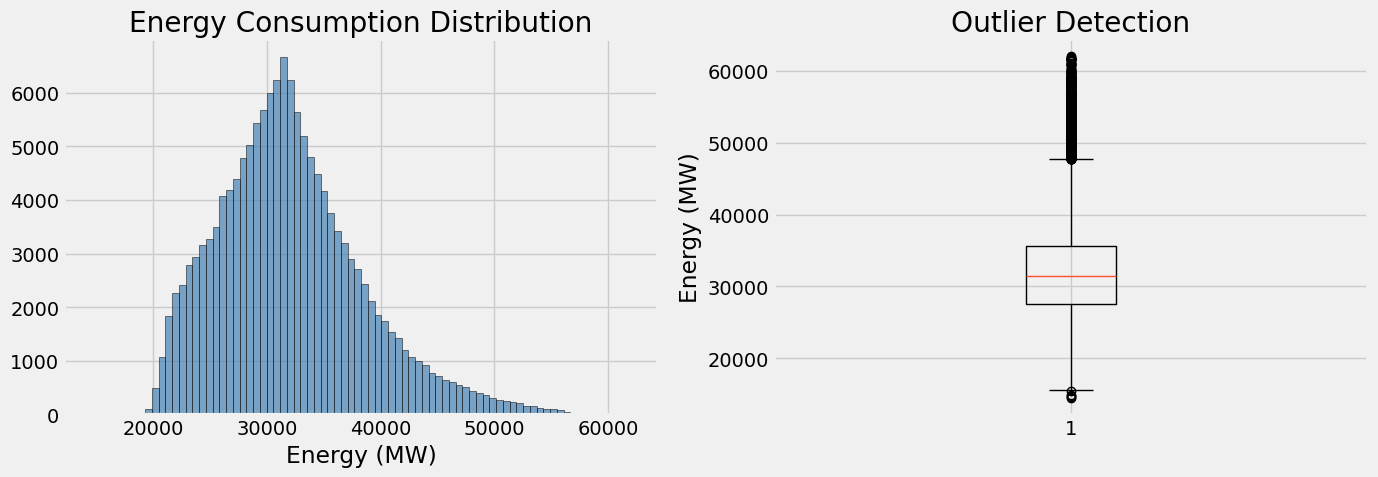

Q1: 27573 | Q3: 35650 | IQR: 8077
Bounds: [15458, 47766]
Outliers: 3455 (2.38%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


df['energy_mw'].hist(bins=80, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Energy Consumption Distribution')
axes[0].set_xlabel('Energy (MW)')


axes[1].boxplot(df['energy_mw'], vert=True)
axes[1].set_title('Outlier Detection')
axes[1].set_ylabel('Energy (MW)')

plt.tight_layout()
plt.show()


Q1 = df['energy_mw'].quantile(0.25)
Q3 = df['energy_mw'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['energy_mw'] < lower) | (df['energy_mw'] > upper)]
print(f"Q1: {Q1:.0f} | Q3: {Q3:.0f} | IQR: {IQR:.0f}")
print(f"Bounds: [{lower:.0f}, {upper:.0f}]")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

In [12]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['energy_mw'], autolag='AIC')
print('ADF Statistic:', f'{result[0]:.4f}')
print('p-value:', f'{result[1]:.6f}')
print('Lags Used:', result[2])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value:.4f}')
    
if result[1] < 0.05:
    print('\n→ Series is STATIONARY (reject null hypothesis)')
else:
    print('\n→ Series is NON-STATIONARY (fail to reject null hypothesis)')

ADF Statistic: -19.8813
p-value: 0.000000
Lags Used: 75
Critical Value (1%): -3.4304
Critical Value (5%): -2.8616
Critical Value (10%): -2.5668

→ Series is STATIONARY (reject null hypothesis)


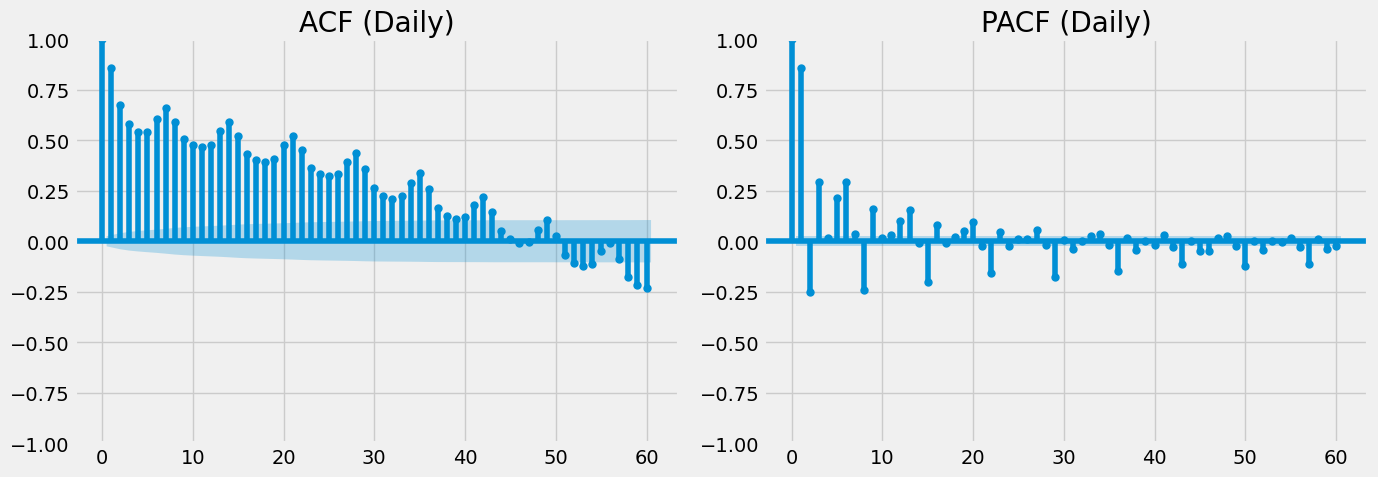

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df_daily = df['energy_mw'].resample('D').mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df_daily.dropna(), lags=60, ax=axes[0], title='ACF (Daily)')
plot_pacf(df_daily.dropna(), lags=60, ax=axes[1], title='PACF (Daily)')
plt.tight_layout()
plt.show()

## EDA Summary

**Key Findings:**
- **16 years** of hourly data (2002-2018), 145K+ records, no missing values
- **Strong seasonality:** Summer & Winter peaks (heating/cooling), Spring & Fall are lower
- **Daily pattern:** Peak consumption around 17:00-19:00, minimum around 04:00-05:00
- **Weekly pattern:** Weekdays consume more energy than weekends
- **Outliers:** Present but minimal — will be handled in preprocessing
- **Stationarity:** [fill after running ADF test]
- **Autocorrelation:** Strong daily and weekly lag patterns — good for forecasting models

**Implications for Modeling:**
- Seasonal decomposition needed before ARIMA
- Prophet can capture multiple seasonality layers (daily, weekly, yearly)
- LSTM can learn complex temporal patterns from raw sequences